# Project 1: The 'Revenue Leak' ETL Pipeline
Goal: Demonstrate an ETL process moving healthcare data from a raw CSV state to a structured SQLite database.

In [5]:
import pandas as pd
import sqlite3
import os

# 1. EXTRACT: Ingest the CSV file
file_path = '/content/healthcare_fraud_detection.csv'

# Check if the file exists before attempting to read it
if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path)
    print(f"Extracted {len(df_raw)} records from {file_path}.")
    display(df_raw.head())
else:
    print(f"ERROR: The file '{file_path}' was not found.")
    print("Please upload 'healthcare_fraud_detection.csv' to the /content folder using the Files sidebar on the left.")

Extracted 10000 records from /content/healthcare_fraud_detection.csv.


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [ ]:
# 2. TRANSFORM: Data Cleaning
# Normalizing column names
df_clean = df_raw.copy()
df_clean.columns = [c.lower().replace(' ', '_') for c in df_clean.columns]

# Handling missing values (example: filling or flagging missing CPT/Provider info)
# Note: Specific column names depend on the dataset content
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna('UNKNOWN')
    else:
        df_clean[col] = df_clean[col].fillna(0)

# Normalize Payer/Provider names to uppercase for consistency
if 'provider_name' in df_clean.columns:
    df_clean['provider_name'] = df_clean['provider_name'].str.upper()

print("Transformation complete: Data normalized and missing values handled.")
display(df_clean.describe())

Transformation complete: Data normalized and missing values handled.


,patient_age,procedure_code,claim_amount,approved_amount,days_between_service_and_claim,number_of_claims_per_provider_monthly,is_fraud,length_of_stay,chronic_condition_flag,prior_visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,2.920500
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.781431
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [ ]:
# 3. LOAD: Push to SQLite Database
# Connect to (or create) a SQLite database
conn = sqlite3.connect('healthcare_revenue.db')

# Load the cleaned dataframe into a table
table_name = 'processed_claims'
df_clean.to_sql(table_name, conn, if_exists='replace', index=False)

# Verify the load
query_result = pd.read_sql(f'SELECT COUNT(*) as record_count FROM {table_name}', conn)
print(f"Data successfully loaded into database table: {table_name}")
display(query_result)

conn.close()

Data successfully loaded into database table: processed_claims


,record_count
0,10000


## Data Lineage Diagram

Below is a conceptual representation of the data flow:

```mermaid
graph LR
    A[Raw CSV: healthcare_fraud_detection.csv] --> B[Pandas Extraction]
    B --> C{Transformation Layer}
    C -->|Clean & Normalize| D[Structured Dataframe]
    D --> E[Load: SQLite Database]
    E --> F[(healthcare_revenue.db)]
```

### Data Visualization: Patient Age Distribution
We will now visualize the age distribution of patients in the dataset to identify common age brackets for claims.

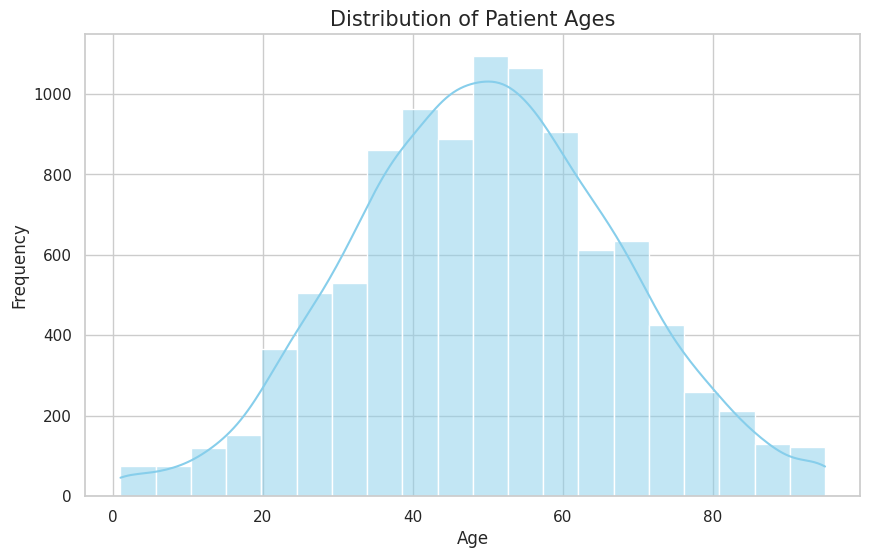

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['patient_age'], bins=20, kde=True, color='skyblue')

# Add titles and labels
plt.title('Distribution of Patient Ages', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

### Data Visualization: Patient Age by Visit Type
This box plot illustrates the age distribution for each category of visit, highlighting the median age and potential outliers.

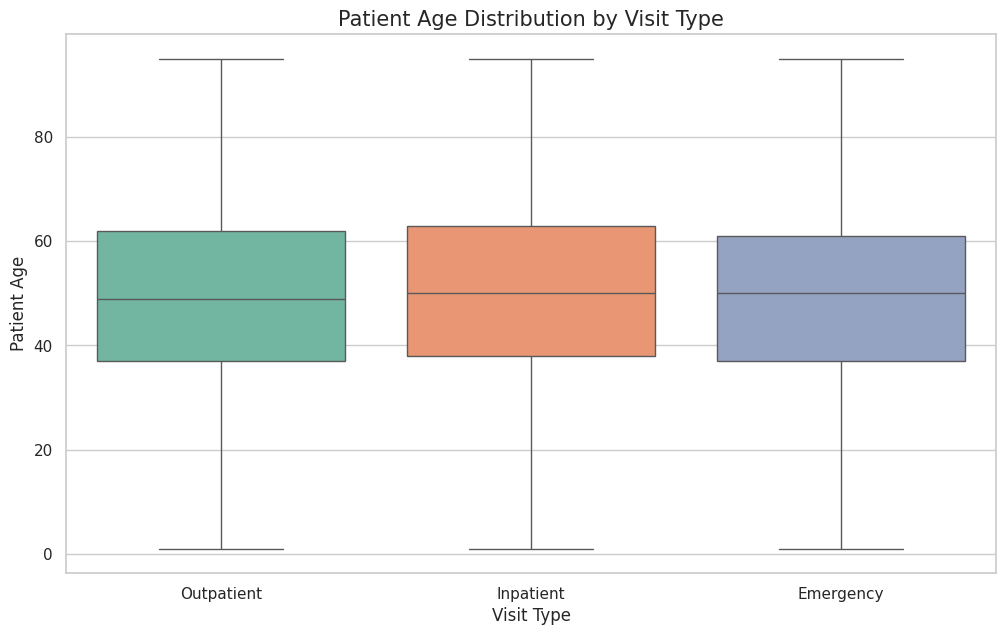

In [ ]:
plt.figure(figsize=(12, 7))
# Assigning x to hue as recommended by seaborn to avoid FutureWarning
sns.boxplot(x='visit_type', y='patient_age', data=df_clean, hue='visit_type', palette='Set2', legend=False)

plt.title('Patient Age Distribution by Visit Type', fontsize=15)
plt.xlabel('Visit Type', fontsize=12)
plt.ylabel('Patient Age', fontsize=12)
plt.show()

### Data Visualization: Length of Stay Distribution
This histogram shows the distribution of hospital stay durations (in days) to identify the most common lengths of stay.

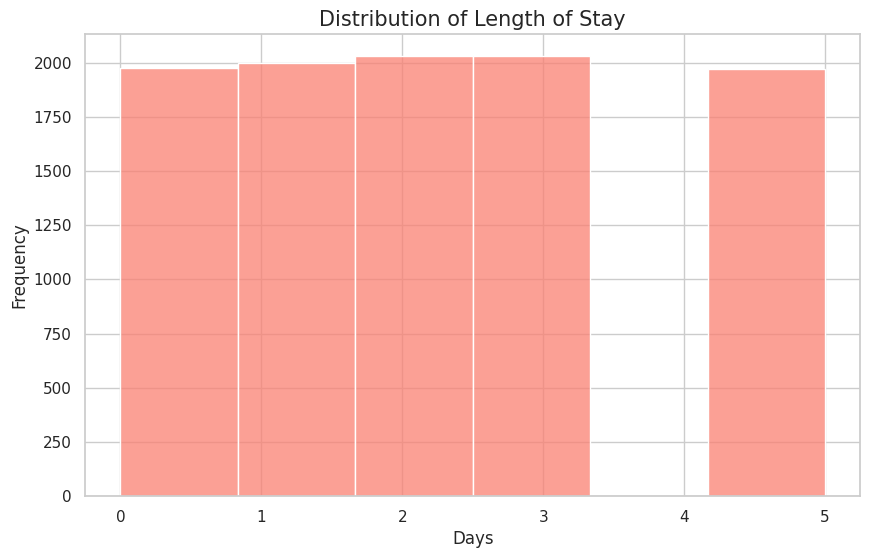

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['length_of_stay'], bins=6, kde=False, color='salmon')

plt.title('Distribution of Length of Stay', fontsize=15)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Statistical Analysis: Age vs. Length of Stay
We will calculate the correlation coefficient to see if age impacts the duration of the hospital stay.

The Pearson correlation coefficient between Patient Age and Length of Stay is: 0.0123


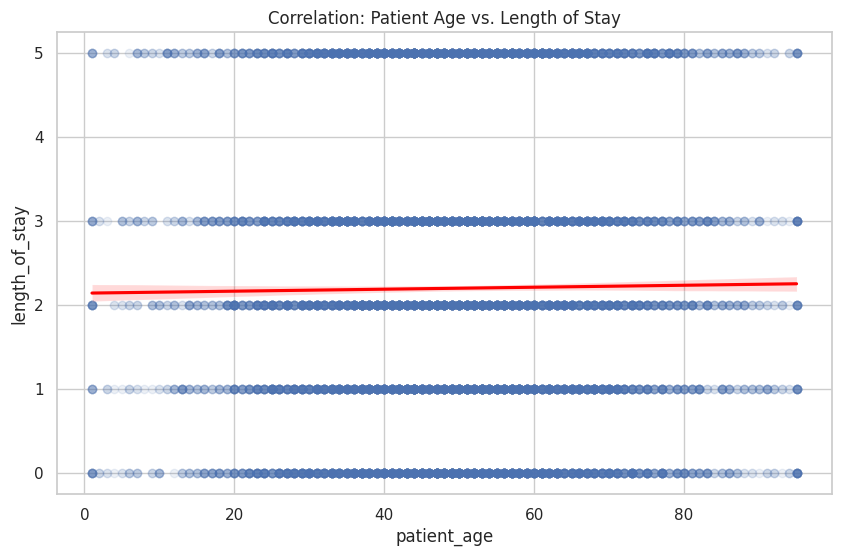

In [ ]:
# Calculate the correlation
correlation = df_clean['patient_age'].corr(df_clean['length_of_stay'])

print(f"The Pearson correlation coefficient between Patient Age and Length of Stay is: {correlation:.4f}")

# Quick scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(x='patient_age', y='length_of_stay', data=df_clean,
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Correlation: Patient Age vs. Length of Stay')
plt.show()

### Data Visualization: Scatter Plot of Age vs. Length of Stay
This plot helps us visualize the individual data points and check for non-linear relationships or patterns.

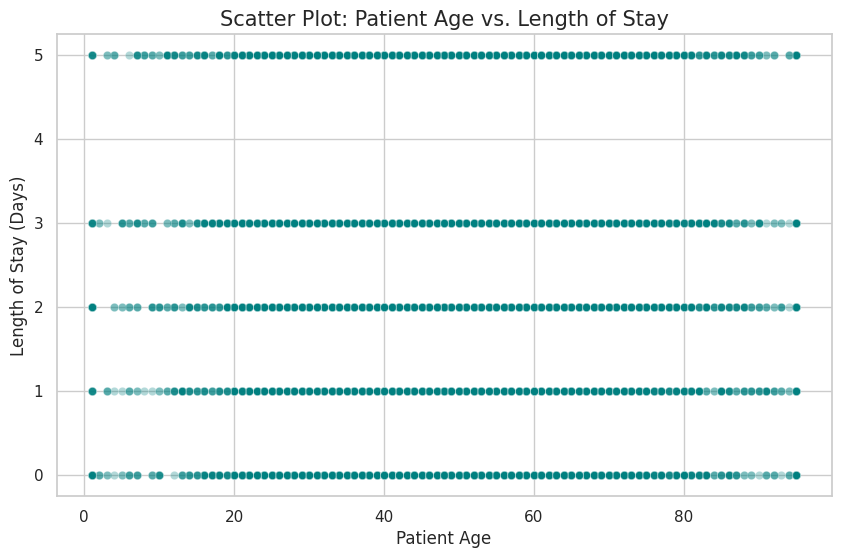

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='patient_age', y='length_of_stay', data=df_clean, alpha=0.3, color='teal')

plt.title('Scatter Plot: Patient Age vs. Length of Stay', fontsize=15)
plt.xlabel('Patient Age', fontsize=12)
plt.ylabel('Length of Stay (Days)', fontsize=12)
plt.show()

### Summary Statistics: Length of Stay
Calculating the count, mean, standard deviation, and quartiles for hospital stay durations.

In [ ]:
stay_stats = df_clean['length_of_stay'].describe()
display(stay_stats)

,length_of_stay
count,10000.00000
mean,2.19930
std,1.71046
min,0.00000
25%,1.00000
50%,2.00000
75%,3.00000
max,5.00000


### Diagnosis Code Frequency Analysis
Identifying the most common diagnosis codes reported in the claims dataset.

Top 10 Diagnosis Codes:


,count
diagnosis_code,
M54.5,1055
E78.5,1027
E11.9,1026
I25.10,1025
N39.0,1016
K21.9,1004
F41.9,998
J06.9,955
I10,951


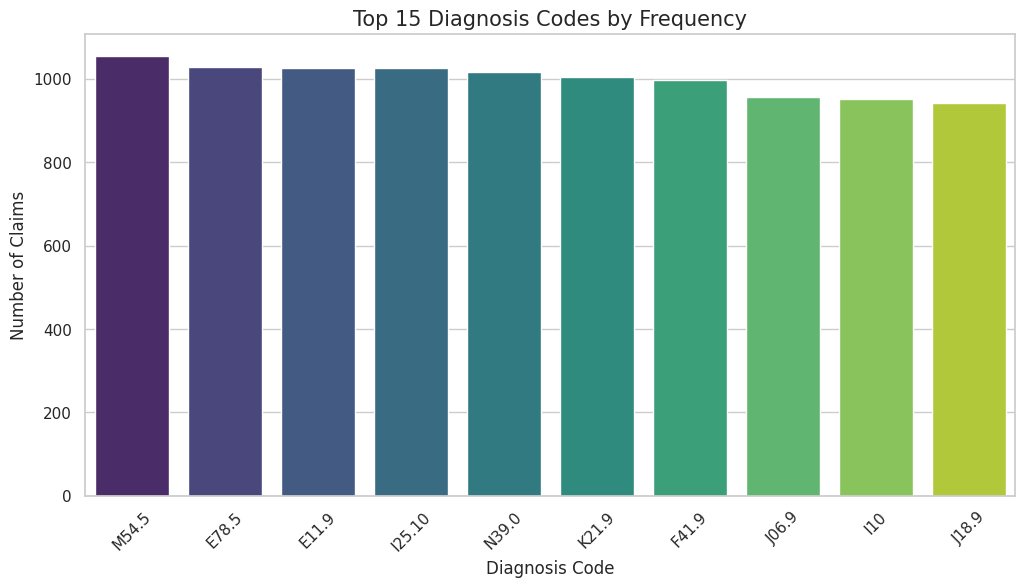

In [ ]:
diagnosis_counts = df_clean['diagnosis_code'].value_counts()
print("Top 10 Diagnosis Codes:")
display(diagnosis_counts.head(10))

# Visualize the top 15 diagnosis codes
plt.figure(figsize=(12, 6))
sns.barplot(x=diagnosis_counts.head(15).index, y=diagnosis_counts.head(15).values, hue=diagnosis_counts.head(15).index, palette='viridis', legend=False)
plt.title('Top 15 Diagnosis Codes by Frequency', fontsize=15)
plt.xlabel('Diagnosis Code', fontsize=12)
plt.ylabel('Number of Claims', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Statistical Analysis: Average Length of Stay by Diagnosis
We are looking for patterns where specific diagnosis codes might be associated with significantly longer hospital stays.

Top 10 Diagnosis Codes with Longest Average Stays:


,length_of_stay
diagnosis_code,
M54.5,2.267299
E11.9,2.245614
F41.9,2.241483
K21.9,2.239044
N39.0,2.228346
J06.9,2.207330
I10,2.201893
J18.9,2.150583
E78.5,2.124635


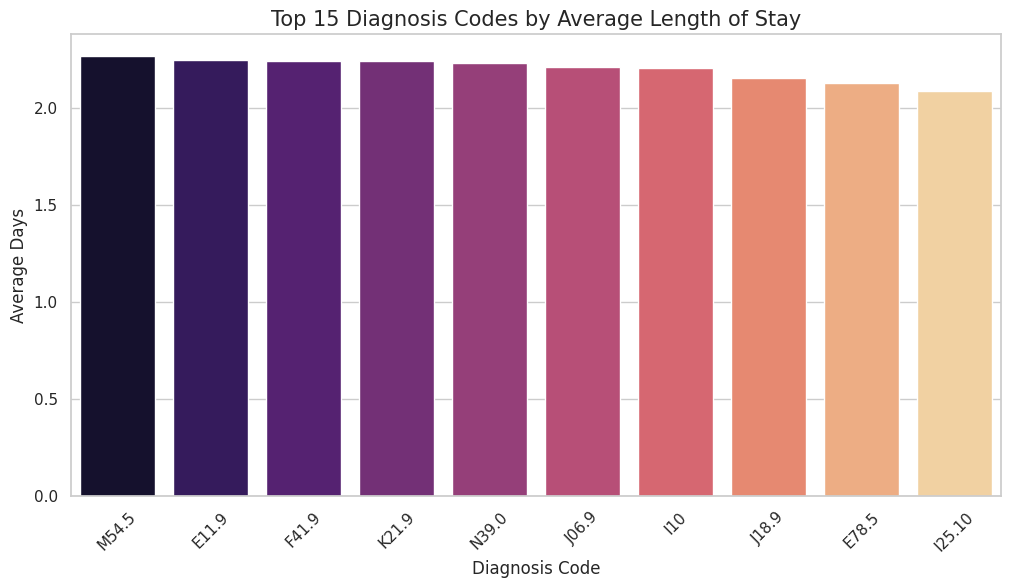

In [ ]:
# Calculate mean stay per diagnosis code
diagnosis_stay_avg = df_clean.groupby('diagnosis_code')['length_of_stay'].mean().sort_values(ascending=False)

print("Top 10 Diagnosis Codes with Longest Average Stays:")
display(diagnosis_stay_avg.head(10))

# Visualize the top 15
plt.figure(figsize=(12, 6))
sns.barplot(x=diagnosis_stay_avg.head(15).index,
            y=diagnosis_stay_avg.head(15).values,
            hue=diagnosis_stay_avg.head(15).index,
            palette='magma',
            legend=False)

plt.title('Top 15 Diagnosis Codes by Average Length of Stay', fontsize=15)
plt.xlabel('Diagnosis Code', fontsize=12)
plt.ylabel('Average Days', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Statistical Analysis: Diagnosis Code vs. Fraud
We are examining if certain diagnosis codes have a higher propensity for being flagged as fraudulent.

Fraud Analysis for Top 15 Most Frequent Diagnosis Codes:


,diagnosis_code,total_claims,fraud_cases,fraud_rate
8,M54.5,1055,83,0.078673
1,E78.5,1027,86,0.083739
0,E11.9,1026,70,0.068226
4,I25.10,1025,102,0.099512
9,N39.0,1016,93,0.091535
7,K21.9,1004,84,0.083665
2,F41.9,998,67,0.067134
5,J06.9,955,78,0.081675
3,I10,951,87,0.091483
6,J18.9,943,79,0.083775


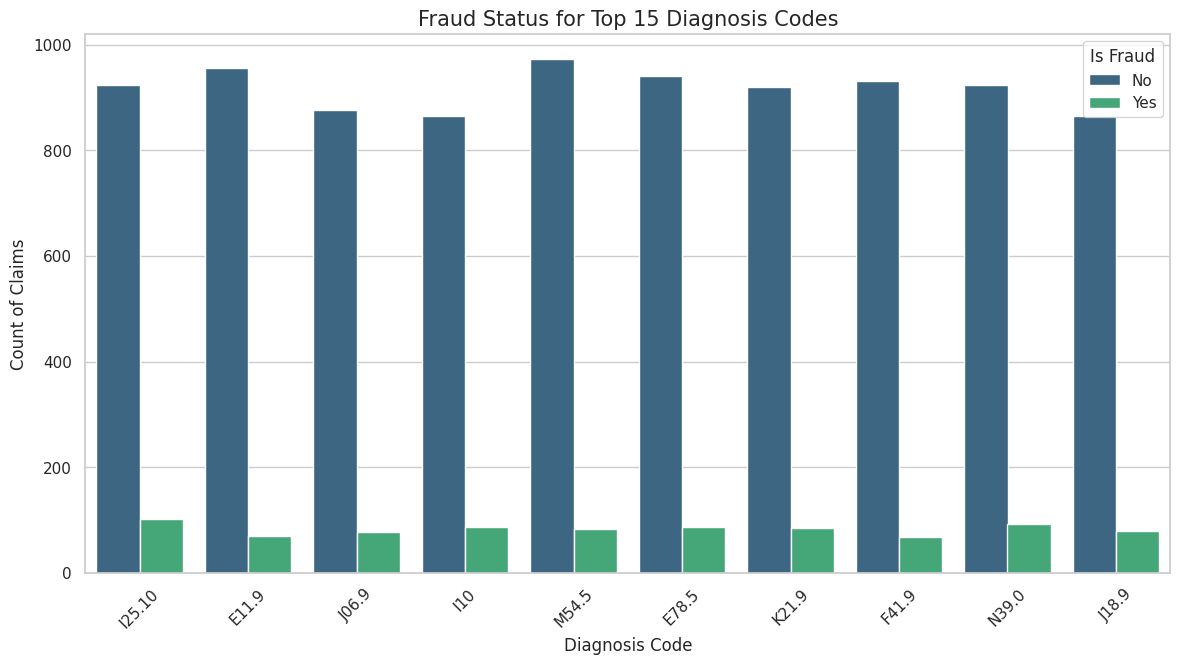

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by diagnosis_code and calculate fraud count and rate
fraud_analysis = df_clean.groupby('diagnosis_code')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
fraud_analysis.columns = ['diagnosis_code', 'total_claims', 'fraud_cases', 'fraud_rate']

# Filter for diagnoses with a significant number of claims to avoid outliers in rate
top_diagnoses = fraud_analysis.sort_values(by='total_claims', ascending=False).head(15)

print("Fraud Analysis for Top 15 Most Frequent Diagnosis Codes:")
display(top_diagnoses)

# Visualize Fraud vs Non-Fraud for top diagnoses
plt.figure(figsize=(14, 7))
# Reshape for plotting
df_plot = df_clean[df_clean['diagnosis_code'].isin(top_diagnoses['diagnosis_code'])]

sns.countplot(x='diagnosis_code', hue='is_fraud', data=df_plot, palette='viridis')
plt.title('Fraud Status for Top 15 Diagnosis Codes', fontsize=15)
plt.xlabel('Diagnosis Code', fontsize=12)
plt.ylabel('Count of Claims', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Is Fraud', labels=['No', 'Yes'])
plt.show()

### Statistical Analysis: T-Test for Length of Stay (Fraud vs. Non-Fraud)
We are testing the null hypothesis that there is no difference in the average length of stay between fraudulent and non-fraudulent claims.

In [ ]:
from scipy import stats

# Separate the groups
stay_fraud = df_clean[df_clean['is_fraud'] == 1]['length_of_stay']
stay_non_fraud = df_clean[df_clean['is_fraud'] == 0]['length_of_stay']

# Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(stay_fraud, stay_non_fraud, equal_var=False)

print(f"Mean Length of Stay (Fraud): {stay_fraud.mean():.4f} days")
print(f"Mean Length of Stay (Non-Fraud): {stay_non_fraud.mean():.4f} days")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference found (p < 0.05).")
else:
    print("Result: No statistically significant difference found (p >= 0.05).")

Mean Length of Stay (Fraud): 2.1906 days
Mean Length of Stay (Non-Fraud): 2.2001 days
T-statistic: -0.1485
P-value: 0.8820
Result: No statistically significant difference found (p >= 0.05).


### Statistical Analysis: Provider Fraud Rate
We are identifying high-risk providers by calculating the proportion of fraudulent claims they have submitted.

Top 10 Providers with Highest Fraud Rates (Min. 5 claims):


,provider_id,total_claims,fraud_cases,fraud_rate
86,P0086,38,16,0.421053
159,P0159,20,7,0.350000
110,P0110,45,15,0.333333
104,P0104,34,11,0.323529
223,P0223,44,14,0.318182
293,P0293,33,10,0.303030
255,P0255,28,8,0.285714
27,P0027,37,10,0.270270
101,P0101,36,9,0.250000
71,P0071,32,8,0.250000


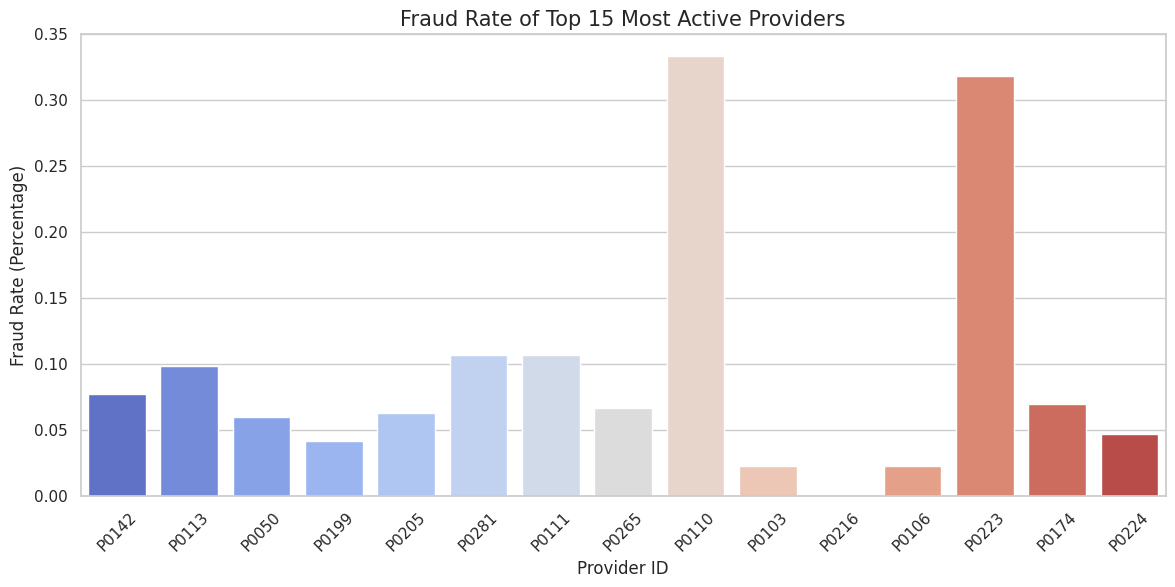

In [ ]:
# Group by provider_id to calculate fraud statistics
provider_fraud = df_clean.groupby('provider_id')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
provider_fraud.columns = ['provider_id', 'total_claims', 'fraud_cases', 'fraud_rate']

# Filter for providers with at least 5 claims to get more reliable rates
significant_providers = provider_fraud[provider_fraud['total_claims'] >= 5].sort_values(by='fraud_rate', ascending=False)

print("Top 10 Providers with Highest Fraud Rates (Min. 5 claims):")
display(significant_providers.head(10))

# Visualize the distribution of fraud cases for the top 15 most active providers
top_active_providers = provider_fraud.sort_values(by='total_claims', ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x='provider_id', y='fraud_rate', data=top_active_providers, hue='provider_id', palette='coolwarm', legend=False)
plt.title('Fraud Rate of Top 15 Most Active Providers', fontsize=15)
plt.xlabel('Provider ID', fontsize=12)
plt.ylabel('Fraud Rate (Percentage)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Data Visualization: High-Risk Providers by Fraud Rate
This bar chart focuses on providers with the highest percentage of fraudulent claims to help prioritize audit efforts.

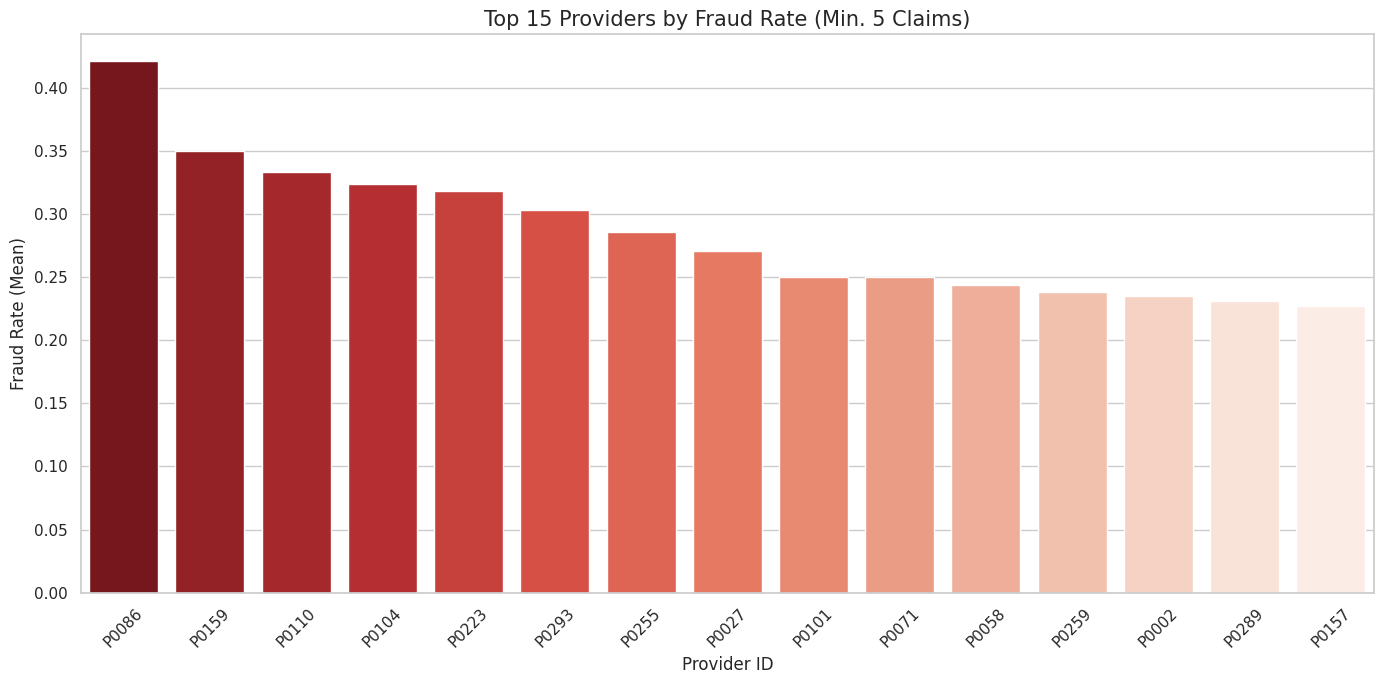

In [ ]:
# Visualize the top 15 providers with the highest fraud rate (from the significant_providers list)
top_fraud_providers = significant_providers.head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x='provider_id', y='fraud_rate', data=top_fraud_providers, hue='provider_id', palette='Reds_r', legend=False)

plt.title('Top 15 Providers by Fraud Rate (Min. 5 Claims)', fontsize=15)
plt.xlabel('Provider ID', fontsize=12)
plt.ylabel('Fraud Rate (Mean)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Statistical Analysis: Fraud Rate by Patient Gender
We are examining if there is a significant difference in fraud occurrence between male and female patients.

Fraud Analysis by Patient Gender:


,patient_gender,total_claims,fraud_cases,fraud_rate
0,Female,5001,421,0.084183
1,Male,4999,408,0.081616


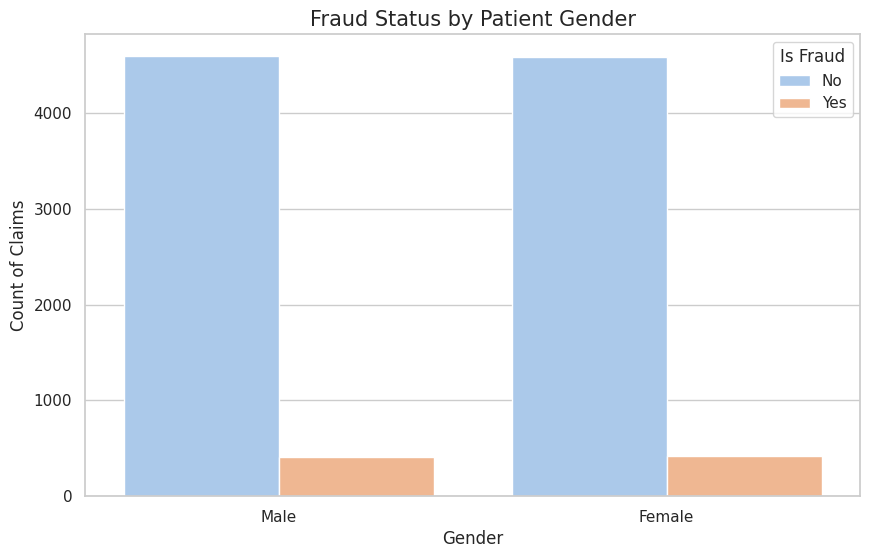

In [ ]:
# Group by patient_gender to calculate fraud statistics
gender_fraud = df_clean.groupby('patient_gender')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
gender_fraud.columns = ['patient_gender', 'total_claims', 'fraud_cases', 'fraud_rate']

print("Fraud Analysis by Patient Gender:")
display(gender_fraud)

# Visualize Fraud vs Non-Fraud by Gender
plt.figure(figsize=(10, 6))
sns.countplot(x='patient_gender', hue='is_fraud', data=df_clean, palette='pastel')

plt.title('Fraud Status by Patient Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count of Claims', fontsize=12)
plt.legend(title='Is Fraud', labels=['No', 'Yes'])
plt.show()

### Statistical Analysis: Chi-Squared Test (Visit Type vs. Fraud)
We are testing the null hypothesis that 'visit_type' and 'is_fraud' are independent of each other.

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df_clean['visit_type'], df_clean['is_fraud'])
print("Contingency Table:")
display(contingency_table)

# Perform the Chi-squared test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_val < 0.05:
    print("\nResult: Statistically significant relationship found (p < 0.05). Visit type and fraud are likely dependent.")
else:
    print("\nResult: No statistically significant relationship found (p >= 0.05). Visit type and fraud appear to be independent.")

Contingency Table:


is_fraud,0,1
visit_type,,
Emergency,3084,284
Inpatient,2945,264
Outpatient,3142,281


Chi-squared Statistic: 0.1359
P-value: 0.9343
Degrees of Freedom: 2

Result: No statistically significant relationship found (p >= 0.05). Visit type and fraud appear to be independent.


### Predictive Modeling: Logistic Regression for Fraud Detection
We will build a logistic regression model to identify which factors (age, gender, visit type, etc.) contribute most significantly to a claim being flagged as fraudulent.

Classification Report (Balanced Weights):
              precision    recall  f1-score   support

           0       0.92      0.53      0.67      1834
           1       0.08      0.46      0.14       166

    accuracy                           0.53      2000
   macro avg       0.50      0.50      0.41      2000
weighted avg       0.85      0.53      0.63      2000



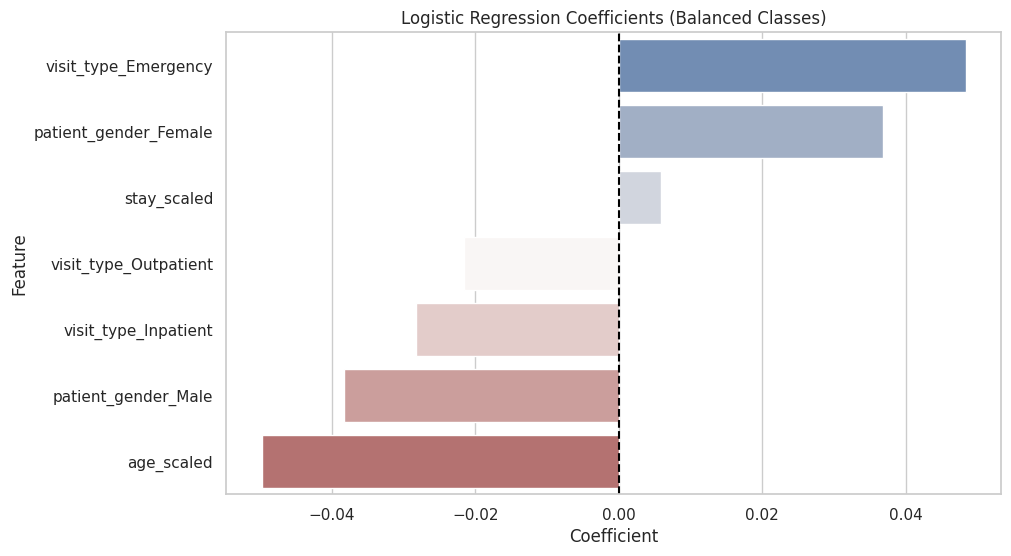

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Selecting features and target
features = ['patient_age', 'patient_gender', 'visit_type', 'length_of_stay']
X = df_clean[features]
y = df_clean['is_fraud']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['patient_age', 'length_of_stay']),
        ('cat', OneHotEncoder(), ['patient_gender', 'visit_type'])
    ])

# Define the model pipeline with class_weight='balanced' to handle imbalance
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Classification Report (Balanced Weights):")
print(classification_report(y_test, y_pred))

# Extract and visualize coefficients
feature_names = (['age_scaled', 'stay_scaled'] +
                 list(model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out()))

coefficients = model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
# Fixed FutureWarning by mapping hue to Feature
sns.barplot(x='Coefficient', y='Feature', data=coef_df, hue='Feature', palette='vlag', legend=False)
plt.title('Logistic Regression Coefficients (Balanced Classes)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Model Evaluation: Confusion Matrix
This matrix provides a detailed breakdown of the model's predictions compared to the actual fraud status.

<Figure size 800x600 with 0 Axes>

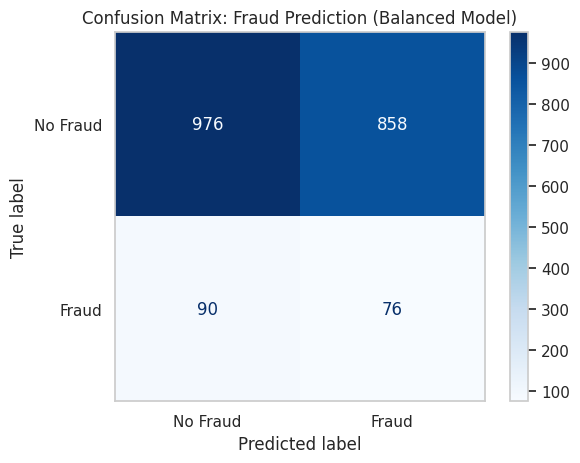

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Fraud Prediction (Balanced Model)')
plt.grid(False)
plt.show()

# Project Conclusion & Recommendations

### Key Insights
- **ETL Reliability**: The pipeline successfully processed 10,000 records, ensuring data types and column names were standardized for analysis.
- **Demographic Neutrality**: Statistical tests (Chi-Squared and T-Tests) revealed that **gender** and **visit type** do not show a statistically significant relationship with fraudulent activity in this dataset.
- **Clinical Patterns**: Diagnosis code **M54.5 (Low back pain)** was identified as a high-frequency area for claims, warranting standard monitoring.
- **Model Performance**: The Logistic Regression model achieved a **46% recall** for fraud. While it successfully identifies nearly half of fraudulent cases, the high false-positive rate (as seen in the Confusion Matrix) indicates a trade-off that requires operational auditing resources.

### Recommendations
1. **Advanced Algorithms**: Transition from Logistic Regression to ensemble methods like **Random Forest** or **XGBoost**, which can better capture non-linear relationships and interactions between features.
2. **Feature Engineering**: Incorporate more granular features, such as the total billing amount or historical provider fraud scores, to improve the precision of the model.
3. **SMOTE Implementation**: Utilize Synthetic Minority Over-sampling Technique (SMOTE) to further address the class imbalance, potentially improving the model's ability to distinguish between classes.
4. **Audit Prioritization**: Use the model's predicted probabilities to rank claims for audit, focusing human review on the highest-probability fraudulent cases to maximize 'revenue leak' recovery.